# GA Optimization Notebook

**Purpose:** Use the same workflow for *any* dataset where the **last column** is the response to optimize and the previous columns are numeric process parameters.  
- Works for **any number of parameters** (N≥1).  
- Choose **minimize or maximize**


**Usage:**  
1. Run the setup cell to install/import.  
2. Load your dataset (CSV or Excel).  
3. run GA.  

In [ ]:
# Setup: install & imports
!pip -q install deap scikit-learn openpyxl

import math, random, sys, os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6,4)


In [ ]:
PROBLEM_SENSE = 'min'   # <- change to 'max' if you want to maximize the last column

# Math poly function degree
POLY_DEGREE = 2

# Cross-validation folds
CV_FOLDS = 5

# GA hyperparameters
POP_SIZE = 100
N_GEN    = 120
CX_PB    = 0.90
MUT_PB   = 0.15

# When auto-deriving bounds from data, expand by this margin (e.g., 0.05 = 5% on each side)
BOUNDS_MARGIN = 0.05


In [ ]:
# Use this if you're uploading the Excel directly in Colab
from google.colab import files
uploaded = files.upload()  # pick the manufacturing_GA_dataset.xlsx you downloaded
excel_path = list(uploaded.keys())[0]

df = pd.read_excel(excel_path, sheet_name="data")
df.head()

print(df.head())
print(f"Shape: {df.shape}  (rows, cols)")


Saving welding_porosity_dataset.xlsx to welding_porosity_dataset (2).xlsx
   wire_feed_mpm  voltage_V  gas_flow_Lmin  travel_speed_mms  porosity_pct
0              3         18             12                 2        4.2799
1              3         18             12                 4        3.0951
2              3         18             12                 6        2.9083
3              3         18             12                 8        3.8055
4              3         18             18                 2        3.6919
Shape: (256, 5)  (rows, cols)


In [ ]:
# ==== 4) Prepare X (features) and y (response) ====
# Rule: last column is the response to optimize; previous columns must be numeric.
all_cols = list(df.columns)
y_col = all_cols[-1]
X_cols = all_cols[:-1]

# Keep only numeric columns among X
numeric_cols = [c for c in X_cols if pd.api.types.is_numeric_dtype(df[c])]
if len(numeric_cols) != len(X_cols):
    dropped = set(X_cols) - set(numeric_cols)
    print(f"Non-numeric feature columns dropped: {sorted(list(dropped))}")
X_cols = numeric_cols

# Drop rows with NA in any X or y
work = df[X_cols + [y_col]].dropna().copy()
X = work[X_cols].values
y = work[y_col].values

print(f"Features (X_cols): {X_cols}")
print(f"Response (y_col): {y_col}")
print(f"Usable rows after NA drop: {len(work)} of {len(df)}")


Features (X_cols): ['wire_feed_mpm', 'voltage_V', 'gas_flow_Lmin', 'travel_speed_mms']
Response (y_col): porosity_pct
Usable rows after NA drop: 256 of 256


In [ ]:
# ==== 5) Derive or set bounds ====
# Default: auto-derive from data min/max and expand by BOUNDS_MARGIN.
bounds = {}
for i, c in enumerate(X_cols):
    xmin, xmax = float(np.min(X[:, i])), float(np.max(X[:, i]))
    span = xmax - xmin if xmax > xmin else max(1.0, abs(xmax))  # avoid zero span
    lo = xmin - BOUNDS_MARGIN * span
    hi = xmax + BOUNDS_MARGIN * span
    bounds[c] = (lo, hi)

print("Auto-derived bounds (edit in-place if needed):")
for k, (lo, hi) in bounds.items():
    print(f"  {k}: [{lo:.6g}, {hi:.6g}]")

# OPTIONAL: You can override any bound explicitly, e.g.:
# bounds['speed_rpm'] = (1100.0, 2400.0)


Auto-derived bounds (edit in-place if needed):
  wire_feed_mpm: [2.7, 9.3]
  voltage_V: [17.55, 27.45]
  gas_flow_Lmin: [11.1, 30.9]
  travel_speed_mms: [1.7, 8.3]


In [ ]:
# ==== 6) Fit polynomial surrogate ====
model = Pipeline([
    ("scale", StandardScaler()),
    ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
    ("lin",  LinearRegression())
])

if CV_FOLDS and CV_FOLDS > 1:
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    mae = -cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=kf).mean()
    r2  =  cross_val_score(model, X, y, scoring="r2", cv=kf).mean()
    print(f"Polynomial surrogate (deg={POLY_DEGREE}) CV -> MAE: {mae:.4f}, R²: {r2:.3f}")
else:
    print(f"Polynomial surrogate (deg={POLY_DEGREE}) CV skipped.")

model.fit(X, y)

def predict_response(x_vec):
    x2d = np.array(x_vec, dtype=float).reshape(1, -1)
    return float(model.predict(x2d)[0])


Polynomial surrogate (deg=2) CV -> MAE: 0.0435, R²: 0.995


In [ ]:
# ==== 7) GA setup & run (DEAP) ====
# We'll always minimize internally; for maximize, we minimize the negative response.
minimize_mode = (PROBLEM_SENSE.lower() == 'min')

# Build ordered LOWER/UPPER lists from 'bounds' using X_cols order
LOWER = [bounds[c][0] for c in X_cols]
UPPER = [bounds[c][1] for c in X_cols]

# Reproducibility
random.seed(42)
np.random.seed(42)

# Create DEAP classes once
try:
    creator.FitnessMin
except AttributeError:
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # minimize
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Init: uniform within bounds
def init_uniform(low, up):
    return [random.uniform(l, u) for l, u in zip(low, up)]

toolbox.register("individual", tools.initIterate, creator.Individual, lambda: init_uniform(LOWER, UPPER))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Objective with sign flip for maximize
def eval_obj(ind):
    raw = predict_response(ind)
    val = raw if minimize_mode else -raw
    return (val,)

toolbox.register("evaluate", eval_obj)

# Bounded operators (lists required)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=LOWER, up=UPPER, eta=20.0)
toolbox.register("mutate", tools.mutPolynomialBounded,   low=LOWER, up=UPPER, eta=20.0, indpb=1.0/len(LOWER))
toolbox.register("select", tools.selTournament, tournsize=3)

# GA run
pop = toolbox.population(n=POP_SIZE)
hof = tools.HallOfFame(maxsize=5)

stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

pop, logbook = algorithms.eaSimple(
    population=pop,
    toolbox=toolbox,
    cxpb=CX_PB,
    mutpb=MUT_PB,
    ngen=N_GEN,
    stats=stats,
    halloffame=hof,
    verbose=True
)


gen	nevals	avg    	std     	min    	max    
0  	100   	2.23632	0.645342	1.01804	3.96509
1  	87    	1.67676	0.395792	0.930146	2.87716
2  	92    	1.37108	0.313395	0.882856	2.11992
3  	93    	1.11963	0.152745	0.904008	1.61584
4  	79    	1.01516	0.0777321	0.893865	1.34185
5  	94    	0.96414	0.0444969	0.865955	1.07111
6  	95    	0.921463	0.030748 	0.864007	1.01072
7  	98    	0.900962	0.0290568	0.834805	0.984359
8  	92    	0.877225	0.0228028	0.823631	0.937602
9  	92    	0.863348	0.0303569	0.811502	1.04842 
10 	90    	0.847125	0.0182046	0.811502	0.898338
11 	85    	0.837007	0.0330662	0.809744	1.06511 
12 	88    	0.822773	0.0145114	0.805909	0.894899
13 	90    	0.813917	0.00503558	0.804869	0.831921
14 	88    	0.814522	0.0305209 	0.803058	1.10745 
15 	88    	0.809744	0.00961602	0.803058	0.875683
16 	93    	0.807603	0.0116347 	0.80194 	0.882014
17 	88    	0.805254	0.00659948	0.801906	0.855046
18 	84    	0.804838	0.00669524	0.801548	0.858403
19 	95    	0.805496	0.0107737 	0.801309	0.867785
20 	93 

In [ ]:
# ==== 8) Results & comparison to best row in dataset ====

best = hof[0]
best_raw = predict_response(best)                 # true-scale prediction

print("\n=== GA Result (Predicted) ===")
for name, val in zip(X_cols, best):
    print(f"  {name:>20s} = {val:.6g}")
print(f"\nPredicted {y_col} ({PROBLEM_SENSE}): {best_raw:.6g}")

# Compare vs dataset best according to PROBLEM_SENSE
if PROBLEM_SENSE.lower() == 'min':
    idx_best = work[y_col].idxmin()
    ds_best_val = float(work.loc[idx_best, y_col])
    delta = ds_best_val - best_raw
    delta_label = "Improvement"
else:
    idx_best = work[y_col].idxmax()
    ds_best_val = float(work.loc[idx_best, y_col])
    delta = best_raw - ds_best_val
    delta_label = "Gain"

print("\n=== Best Row in Dataset (by actual y_col) ===")
print(work.loc[idx_best, X_cols + [y_col]])

print(f"\n{delta_label} (predicted GA vs dataset best): {delta:+.6g}  (units of {y_col})")



=== GA Result (Predicted) ===
         wire_feed_mpm = 6.00813
             voltage_V = 21.9889
         gas_flow_Lmin = 20.0239
      travel_speed_mms = 5.00807

Predicted porosity_pct (min): 0.800611

=== Best Row in Dataset (by actual y_col) ===
wire_feed_mpm        7.0000
voltage_V           21.0000
gas_flow_Lmin       24.0000
travel_speed_mms     4.0000
porosity_pct         1.0414
Name: 153, dtype: float64

Improvement (predicted GA vs dataset best): +0.240789  (units of porosity_pct)


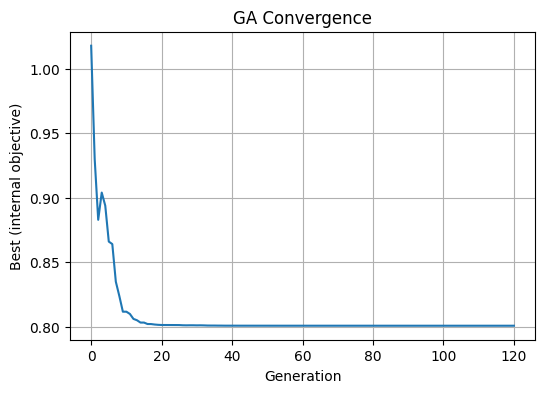

In [ ]:
# ==== 9) Convergence plot ====
mins = [r["min"] for r in logbook]
plt.figure()
plt.plot(mins)
plt.xlabel("Generation")
plt.ylabel("Best (internal objective)")
plt.title("GA Convergence")
plt.grid(True)
plt.show()


In [ ]:
# ==== 10) Save GA best & bounds to an Excel for record ====
out_path = "GA_results_summary.xlsx"
summary = {
    "parameter": X_cols + [y_col],
    "value": list(best) + [best_raw],
}
df_sum = pd.DataFrame(summary)

with pd.ExcelWriter(out_path, engine="xlsxwriter") as w:
    df_sum.to_excel(w, index=False, sheet_name="GA_best" )
    pd.DataFrame({"col": X_cols, "low": [bounds[c][0] for c in X_cols], "high": [bounds[c][1] for c in X_cols]}).to_excel(w, index=False, sheet_name="bounds")
    work.to_excel(w, index=False, sheet_name="data_used" )

print(f"Saved: {out_path}")
